# Одномерная оптимизация (10 баллов)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import itertools

В данном домашнем задании рассматриваются несколько базовых подходов одномерной оптимизации, не использующих знания о градиенте функции. Для его выполнения потребуется следующее определение:

__Определение.__ Одномерная функция $f: [a, b] \to \mathbb{R}$ называется _унимодальной_ на $[a, b]$, если существует $c^{*} \in [a, b]$ такое, что:

1. Для произвольных $x, y \in [a, c^{*}]$, таких что $x < y$, выполнено $f(x) > f(y)$;

2. Для произвольных $x, y \in [c^{*}, b]$, таких что $x < y$, выполнено $f(x) < f(y)$.

Говоря менее формально, мы рассматриваем функции на отрезке, которые строго убывают слева от минимума и строго возрастают справа от него. Из определения незамедлительно следует, что минимум на отрезке $[a, b]$ единственен.

Описание метода __дихотомии__ (бисекции) для поиска минимума унимодальных функций:

1. __Инициализация:__

1.1. Задается унимодальная функция $f(x)$, которая имеет единственный минимум на интервале $[a,b]$.

1.2. Задается начальный интервал $[a,b]$, на котором ищется минимум.

1.3. Задается параметр $\varepsilon$ — точность, с которой нужно найти минимум.

2. __Итеративный шаг метода:__

2.1. Интервал $[a,b]$ делится пополам, и вычисляется середина интервала:

$$c = \frac{a + b}{2}$$

2.2. Выбираются две точки $x_1$ и $x_2$, близкие к середине интервала $c$, но не совпадающие с ней:

$$x_{1} = c - \delta, \quad x_{2} = c + \delta,$$

где $\delta$ небольшое положительное число, обычно $\delta \ll \varepsilon$, поэтому возьмите $\delta = \frac{\varepsilon}{10}$.

2.3. Вычисляются значения функции в точках $x_1$ и $x_2$:

$\bullet$ Если $f(x_{1}) < f(x_{2})$, то минимум находится на отрезке $[a, x_{2}]$, поэтому зона поиска оптимума сужается до $[a, x_2]$.

$\bullet$ Если $f(x_{1}) > f(x_{2})$, то минимум находится на отрезке $[x_{1}, b]$, поэтому зона поиска оптимума сужается до $[x_1, b]$.

$\bullet$ Если $f(x_{1}) = f(x_{2})$, то минимум находится на отрезке $[x_{1}, x_{2}]$, поэтому зона поиска оптимума сужается до $[a, x_{2}]$ или $[x_1, b]$.

3. __Проверка точности:__

$\bullet$ Если длина нового интервала меньше заданной точности $\varepsilon$, то процесс завершается и возвращается значение $c_{\text{out}}$ ($c$ с последней итерации).

$\bullet$ Если длина нового интервала больше заданной точности $\varepsilon$, то повторяется шаг 2 для нового интервала.

__а) (0.5 балла)__ Докажите, что данный алгоритм находит минимум унимодальной функции на отрезке $[a, b]$ с точностью $\varepsilon$ . 

__Решение__

Пусть $c^*$ - минимум $f$ на $[a, b]$. Тогда в соответствии с 3 шагом, $d = |c^* - c_{out}| < \varepsilon$. С другой стороны, т.к. мы работаем на одномерном отрезке $d \overset{def}{=} ||c^* - c_{out}||_1 = ||c^* - c_{out}||_2$, т.е. мы получили определение точности решения задачи по аргументу, ч.т.д.

__б) (0.5 балла)__ Какова будет итерационная и оракульная сложность данного алгоритма для достижения точности $\varepsilon$ (а именно, $|c_{\text{out}} - c^*| \leq \varepsilon$)?

Необходимо получить верхнюю оценку на число итераций и подсчета значений $f$ метода дихотомии для минимизации унимодальных функций.

__Замечание__. Величиной $\delta$ надо пренебречь.

__Решение__

Пренебрегая величиной $\delta$ можно сказать, что на каждой итерации алгоритм делит отрезок пополам. Тогда если $n$ - число итераций до остановки, верно:
$$
\varepsilon \leq \frac{b-a}{2^n} \implies n \leq \log_2(\frac{b-a}{\varepsilon})
$$
т.е. сложность $O(\log(\frac{b-a}{\varepsilon}))$

Заметим, что в каждой итерации происходит 2 обращения к оракулу, т.е. число подсчетов 2 раза больше числа итераций и асимптотическая сложность та же

__в) (1 балл)__ Рассматривается функция

$$f(x) = \tan(\cos(x) - \sin(x))$$

на отрезке $[0; 3]$. 

1. Покажите, что она является унимодальной на этом отрезке (аналитически).

2. Найдите $c^{*}$ (аналитически).

3. Нарисуйте график функции.

__Решение__
$$
f^{\prime} = -(\sin(x) + \cos(x))\sec^2(\cos(x) - \sin(x))
$$

Множитель с секансом конечен и положителен. Тогда точки экстремума $x = \frac{3\pi}{4} + k\pi$. Из них на $[0, 3]$ лежит только

$$
c^* = \frac{3\pi}{4}
$$

$g(x) = \sin(x) + \cos(x)$ непрерывна, $g(0) = 1, g(\pi) = -1$ $\implies$ $f$ строго убывает на $[0, \frac{3\pi}{4})$, строго возрастает на $(\frac{3\pi}{4}, 3]$ и достигает минимума в $c^* = \frac{3\pi}{4}$ 

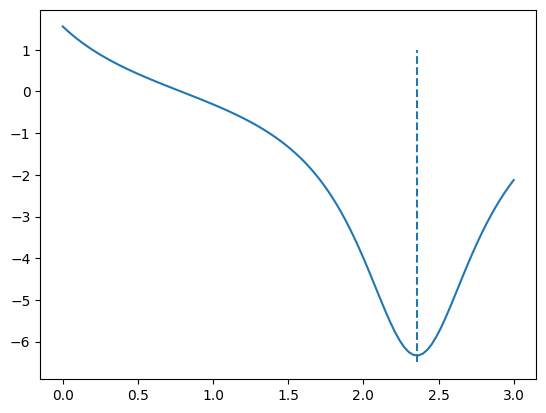

In [2]:
# Ваше решение (Code)

f = lambda x: np.tan(np.cos(x) - np.sin(x))
xaxis = np.linspace(0, 3, 100)
plt.plot(xaxis, f(xaxis))
plt.vlines(3*np.pi/4, -6.5, 1, linestyles="dashed")

__г) (1.5 балла)__ Реализуйте метод дихотомии.

In [3]:
def dichotomy_method(f, a, b, c_star, max_iter=100, eps=1e-6, **params):
    """
    Метод дихотомии для поиска минимума унимодальной функции на интервале [a, b].

    Параметры:
        f (Callable): Унимодальная функция, минимум которой ищется
        a (float): Левая граница интервала поиска
        b (float): Правая граница интервала поиска
        c_star (float): Истинное значение точки минимума (для сравнения)
        max_iter (int, Optional): Максимальное количество итераций
        eps (float, Optional): Точность поиска
            Поиск завершается, когда длина интервала становится меньше eps
        **params: Именованные гиперпараметры метода
            params['delta'] — значение гиперпараметра для поиска точек x1 и x2

    Возвращает:
        c (float): Приближенное значение точки минимума
        history (list): Список значений |c — c_star| на каждой итерации
    """
    
    if a >= b:
        raise ValueError("Левая граница интервала a должна быть меньше правой границы b.")
    if eps <= 0:
        raise ValueError("Точность eps должна быть положительной.")
        
    history = []

    delta = params["delta"] if params["delta"] is not None else eps/10
    #print(a-b, eps, max_iter)

    while b-a>eps and max_iter>0:

        #print(b-a)
        c = (a+b)/2
        history.append(np.abs(c - c_star))

        x1 = c-delta
        x2 = c+delta

        if f(x1) < f(x2):
            b = x2
        else:
            a = x1
        
        max_iter-=1

    history.append(np.abs((a+b)/2-c_star))
    return (a+b)/2, history

Постройте сравнительный график зависимости точности метода $|c_{\text{out}} - c^*|$ и теоретической оценки от числа итераций. Значение $\delta$ выберите равным $10^{-8} \cdot (b - a)$. График должен соответствовать следующим критериям:

1. Размер должен быть удобен для чтения
2. Масштаб осей (обычный или логарифмический)
3. Подписи осей 
4. Легенда (так как на графике несколько линий)
5. Толщина/цвет/сетка (на ваше усмотрение, но должно быть читаемо)

In [4]:
# Ваше решение (Code)

def theory(iter, a, b): return (b-a)/np.pow(2, iter)

a = 0
b = 3
c_star = 3*np.pi/4
c, history = dichotomy_method(f, a, b, c_star, delta=1e-8*(b-a))
iters = np.arange(len(history))

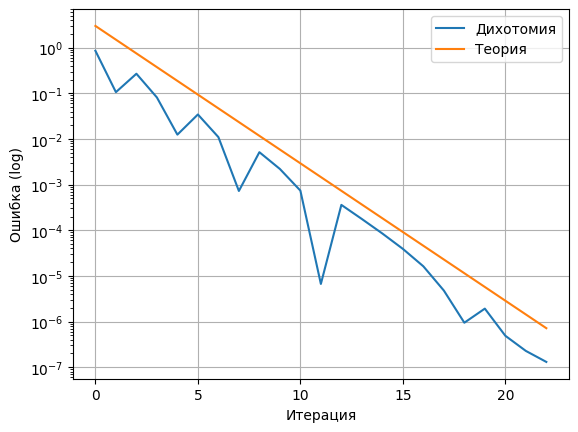

In [5]:
plt.plot(iters, history, label="Дихотомия")
plt.plot(iters, theory(iters, a, b), label="Теория")
plt.xlabel("Итерация")
plt.ylabel("Ошибка (log)")
plt.legend()
plt.grid()
plt.yscale('log')
plt.show()

In [6]:
params={"delta": 1e-8*(b-a)}
params["delta"]

3.0000000000000004e-08

__д) (1 балл)__ Теперь сравним работу метода при разных значениях гиперпараметра $\delta$. Предлагается рассмотреть следующие значения:
1. $\delta = 10^{-12} \cdot (b - a)$;
2. $\delta = 10^{-9} \cdot (b - a)$;
3. $\delta = 10^{-6} \cdot (b - a)$;
4. $\delta = 10^{-3} \cdot (b - a)$;
5. $\delta = 10^{-1} \cdot (b - a)$.

Постройте сравнительный график зависимости критерия от номера итерации.

In [7]:
# Ваше решение (Code)

def plot_for_deltas(f, a, b, c_star, deltas, max_iter=100, eps=1e-6):

    for delta in deltas:

        _, history = dichotomy_method(f, a, b, c_star, max_iter, eps, delta=delta)
        iters = np.arange(len(history))

        plt.plot(iters, history, label=f"$\delta$ = {delta:.2e}")
        plt.xlabel("Итерация")
        plt.ylabel("Ошибка (log)")
    
    #plt.plot(iters, theory(iters, a, b), label="Теория")
    plt.legend()
    plt.grid()
    plt.yscale('log')
    plt.show()

<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:10: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_687677/242063707.py:10: SyntaxWarning: invalid escape sequence '\d'
  plt.plot(iters, history, label=f"$\delta$ = {delta:.2e}")


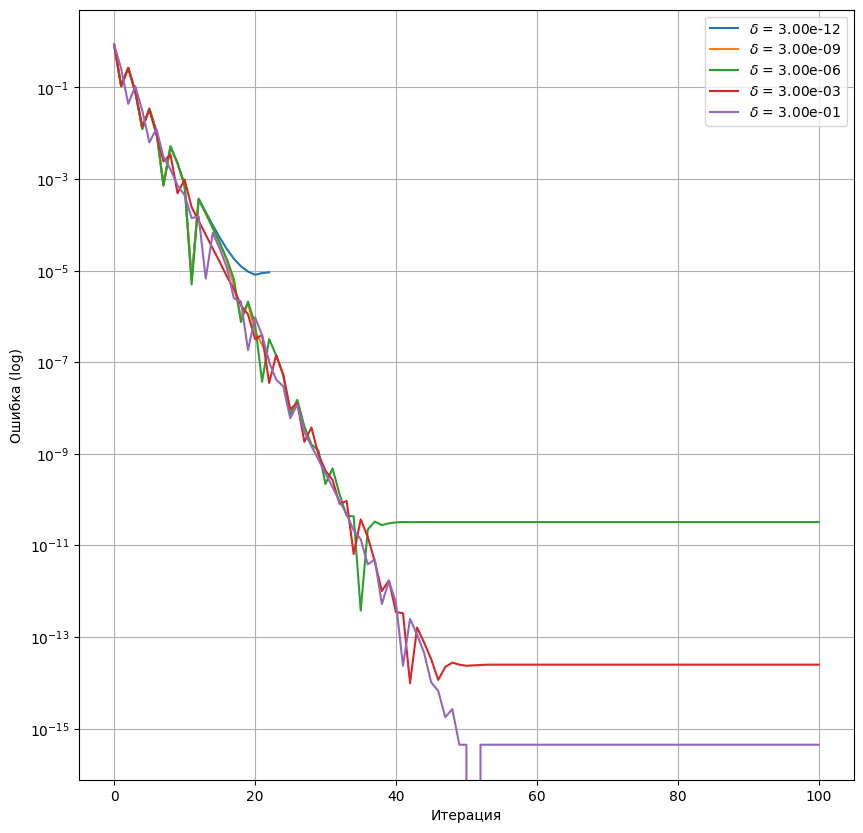

In [8]:
deltas = [1e-12*(b-a), 1e-9*(b-a), 1e-6*(b-a), 1e-3*(b-a), 1e-1*(b-a)]
plt.figure(figsize=(10, 10))
plot_for_deltas(f, a, b, c_star, deltas)
plt.show()

Что можно сказать о зависимости сходимости от значения параметра $\delta$? Объясните, почему для малых значений наблюдается плохая сходимость. Для какого значения наблюдается наилучшая сходимость?

__Решение__ Видно, что чем больше $\delta$, тем хуже сходимость метода. Это можно объяснить тем, что при $\delta \to 0$ метод на каждой итерации делит отрезок пополам. Таким образом размер отрезка очень быстро спадает, хотя мы можем пропускать точку минимума. 

__e) (2 балла)__ До этого использовался подход с использованием постоянной величины $\delta$. Рассмотрим адаптивный подход, а именно — на каждой итерации значение $\delta$ будет определяться через длину интервала $l_k$, полученную на $k$-ой итерации. Предлагается рассмотреть следующие значения:

1. $\delta = 10^{-6} \cdot l_k$;
2. $\delta = 10^{-3} \cdot l_k$;
3. $\delta = 10^{-1} \cdot l_k$;
4. $\delta = 6^{-1} \cdot l_k$.

Последняя модификация также называется __тернарным__ поиском, при котором отрезок делится на 3 части на каждой итерации.

Постройте сравнительный график сходимости значения критерия от различных значений $\delta$. Также добавьте на график сходимость с наилучшим постоянным значением $\delta$, полученным в предыдущем пункте.

In [9]:
def dichotomy_adaptive(f, a, b, c_star, max_iter=100, eps=1e-6, **params):
    """
    Метод дихотомии для поиска минимума унимодальной функции на интервале [a, b].

    Параметры:
        f (Callable): Унимодальная функция, минимум которой ищется
        a (float): Левая граница интервала поиска
        b (float): Правая граница интервала поиска
        c_star (float): Истинное значение точки минимума (для сравнения)
        max_iter (int, Optional): Максимальное количество итераций. По умолчанию 100
        eps (float, Optional): Точность поиска
            Поиск завершается, когда длина интервала становится меньше eps
        **params: Именованные гиперпараметры метода
            params['delta'](a, b) — функция, возвращающая значение интервала на k-ой итерации

    Возвращает:
        c (float): Приближенное значение точки минимума
        history (list): Список значений |c — c_star| на каждой итерации
    """
    
    if a >= b:
        raise ValueError("Левая граница интервала a должна быть меньше правой границы b.")
    if eps <= 0:
        raise ValueError("Точность eps должна быть положительной.")
        
    history = []

    #delta = params["delta"] if params["delta"] is not None else eps/10
    #print(a-b, eps, max_iter)

    while b-a>eps and max_iter>0:

        #print(b-a)
        c = (a+b)/2
        delta = params["delta"](a, b)
        history.append(np.abs(c - c_star))

        x1 = c-delta
        x2 = c+delta

        if f(x1) < f(x2):
            b = x2
        else:
            a = x1

        max_iter-=1

    history.append(np.abs((a+b)/2-c_star))
    return (a+b)/2, history

In [10]:
# Ваше решение (Code)

def plot_for_adaptive_deltas(f, a, b, c_star, deltas, ks, max_iter=100, eps=1e-6):

    for d, delta in enumerate(deltas):

        c, history = dichotomy_adaptive(f, a, b, c_star, max_iter, eps, delta=delta)
        iters = np.arange(len(history))

        plt.plot(iters, history, label=f"$\delta$ = {ks[d]:.2e}$\cdot l_k$")
        plt.xlabel("Итерация")
        plt.ylabel("Ошибка (log)")
    
    #plt.plot(iters, theory(iters, a, b), label="Теория")
    plt.legend()
    plt.grid()
    plt.yscale('log')

<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:10: SyntaxWarning: invalid escape sequence '\c'
<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:10: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_687677/2702335345.py:10: SyntaxWarning: invalid escape sequence '\d'
  plt.plot(iters, history, label=f"$\delta$ = {ks[d]:.2e}$\cdot l_k$")
/tmp/ipykernel_687677/2702335345.py:10: SyntaxWarning: invalid escape sequence '\c'
  plt.plot(iters, history, label=f"$\delta$ = {ks[d]:.2e}$\cdot l_k$")


<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_687677/4085335541.py:8: SyntaxWarning: invalid escape sequence '\d'
  plt.plot(np.arange(len(history)), history, label="$\delta = 1e-1(b-a)$")


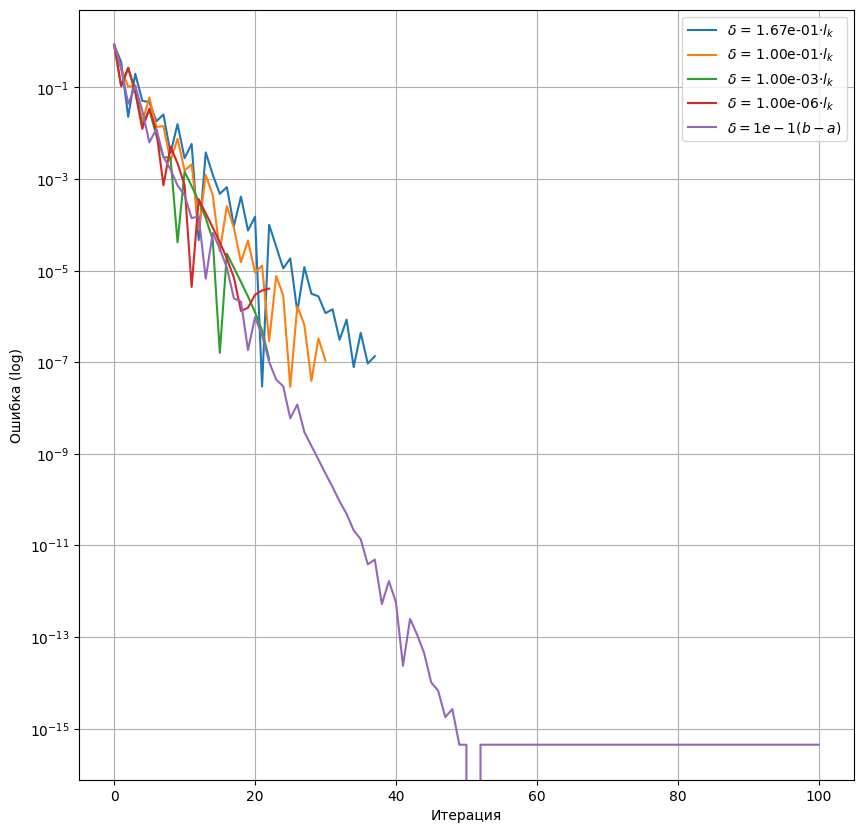

In [11]:
# Ваше решение (Code)
#adapter = lambda a,b: b-a
ks = [1/6, 1/10, 1e-3, 1e-6]
deltas = [lambda a, b, k=k: k*(b-a) for k in ks]
plt.figure(figsize=(10, 10))
plot_for_adaptive_deltas(f, a, b, c_star, deltas, ks)
c, history = dichotomy_method(f, a, b, c_star, delta=1e-1*(b-a))
plt.plot(np.arange(len(history)), history, label="$\delta = 1e-1(b-a)$")
plt.legend()
plt.show()
#deltas

Помогает ли использование адаптивного подхода в достижении лучшей сходимости?

__Решение__ Видим, что лучшая постоянная $\delta$ сходится лучше, но адаптивные методы итеративно быстрее

__ж) (2 балла)__ Реализуйте метод __золотого сечения__. Для этого на каждой итерации подсчитываются точки $x_{1}, x_{2}$, симметричные относительно середины интервала и делящие исходный интервал в пропорции золотого сечения, то есть 1 к $\frac{1 + \sqrt{5}}{2}$. Обновления краевых значений происходит по аналогичной процедуре. 

In [12]:
def golden_ratio_method(f, a, b, c_star, eps=1e-6):
    """
    Метод золотого сечения для поиска минимума унимодальной функции на интервале [a, b].

    Параметры:
        f (Callable): Унимодальная функция, минимум которой ищется
        a (float): Левая граница интервала поиска
        b (float): Правая граница интервала поиска
        c_star (float): Истинное значение точки минимума (для сравнения)
        eps (float, Optional): Точность поиска
            Поиск завершается, когда длина интервала становится меньше eps

    Возвращает:
        c (float): Приближенное значение точки минимума
        history (list): Список значений |c — c_star| на каждой итерации
    """
    
    if a >= b:
        raise ValueError("Левая граница интервала a должна быть меньше правой границы b.")
    if eps <= 0:
        raise ValueError("Точность eps должна быть положительной.")

    history = []
    phi = (np.sqrt(5)-1)/2

    x1 = b - (b-a)*phi
    x2 = a + (b-a)*phi

    f1 = f(x1)
    f2 = f(x2)

    while b-a>eps:

        c = (a+b)/2
        history.append(np.abs(c - c_star))

        if f1 < f2:
            b = x2
            x2 = x1
            x1 = b - phi*(b-a)
            f2 = f1
            f1 = f(x1)
        else:
            a = x1
            x1 = x2
            x2 = a + phi*(b-a)
            f1 = f2
            f2 = f(x2)

    history.append(np.abs((a+b)/2-c_star))
    return (a+b)/2, history


Постройте график сходимости.

/tmp/ipykernel_687677/4093426278.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


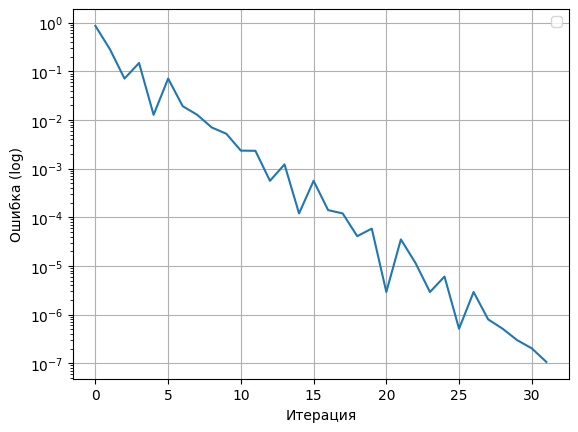

In [13]:
# Ваше решение (Code)
c, history = golden_ratio_method(f, a, b, c_star)
iters = np.arange(len(history))
plt.plot(iters, history)
plt.xlabel("Итерация")
plt.ylabel("Ошибка (log)")
plt.legend()
plt.grid()
plt.yscale('log')
plt.show()

__з) (1.5 балла)__ Постройте сравнительные графики для методов ```dichotomy_method```, ```dichotomy_adaptive``` и ```golden_ratio_method``` для оптимальных значений параметра $\delta$. Первый график должен быть значением критерия от числа итераций.

<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:10: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:10: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_687677/2493853962.py:6: SyntaxWarning: invalid escape sequence '\d'
  plt.plot(iters, history, label=f"Дихотомия с $\delta=1e$-$01\cdot (b-a)$")
/tmp/ipykernel_687677/2493853962.py:10: SyntaxWarning: invalid escape sequence '\d'
  plt.plot(iters, history, label=f"Адаптивная дихотомия с $\delta=1e$-$03\cdot l_k$")


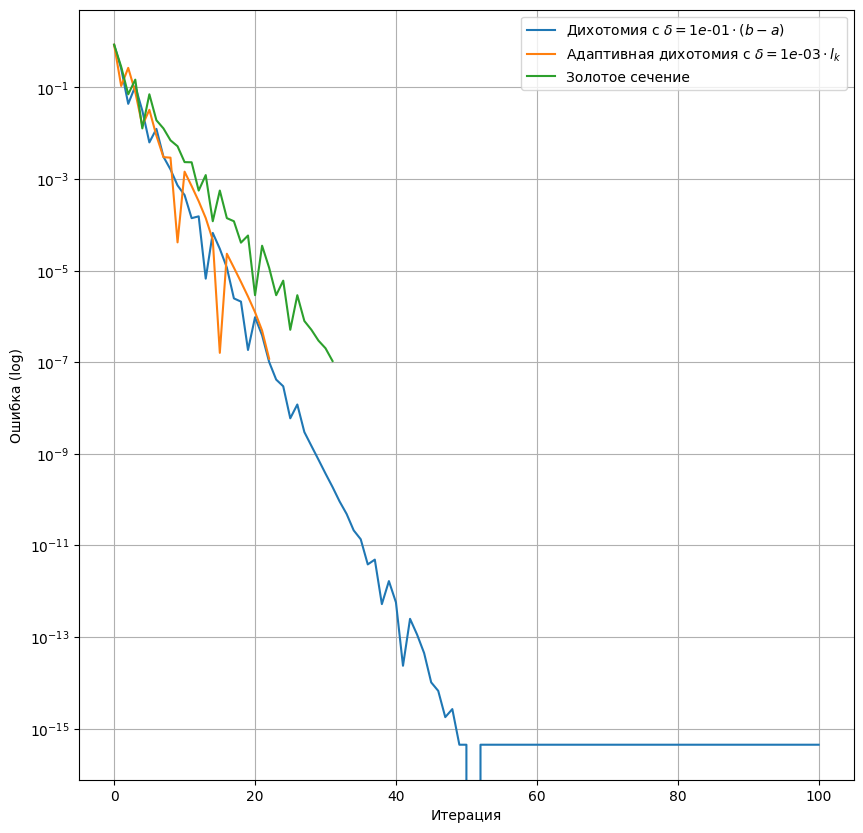

In [14]:
# Ваше решение (Code)
plt.figure(figsize=(10, 10))

c, history = dichotomy_method(f, a, b, c_star, delta=1e-1*(b-a))
iters = np.arange(len(history))
plt.plot(iters, history, label=f"Дихотомия с $\delta=1e$-$01\cdot (b-a)$")

c, history = dichotomy_adaptive(f, a, b, c_star, delta=lambda a,b: 1e-3*(b-a))
iters = np.arange(len(history))
plt.plot(iters, history, label=f"Адаптивная дихотомия с $\delta=1e$-$03\cdot l_k$")

c, history = golden_ratio_method(f, a, b, c_star)
iters = np.arange(len(history))
plt.plot(iters, history, label=f"Золотое сечение")

plt.xlabel("Итерация")
plt.ylabel("Ошибка (log)")
plt.legend()
plt.grid()
plt.yscale('log')
plt.show()

Второй — критерий от количества вызовов функции $f$.

<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:11: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_687677/630415939.py:7: SyntaxWarning: invalid escape sequence '\d'
  plt.plot(fcalls, history, label=f"Дихотомия с $\delta=1e$-$01\cdot (b-a)$")
/tmp/ipykernel_687677/630415939.py:11: SyntaxWarning: invalid escape sequence '\d'
  plt.plot(fcalls, history, label=f"Адаптивная дихотомия с $\delta=1e$-$03\cdot l_k$")


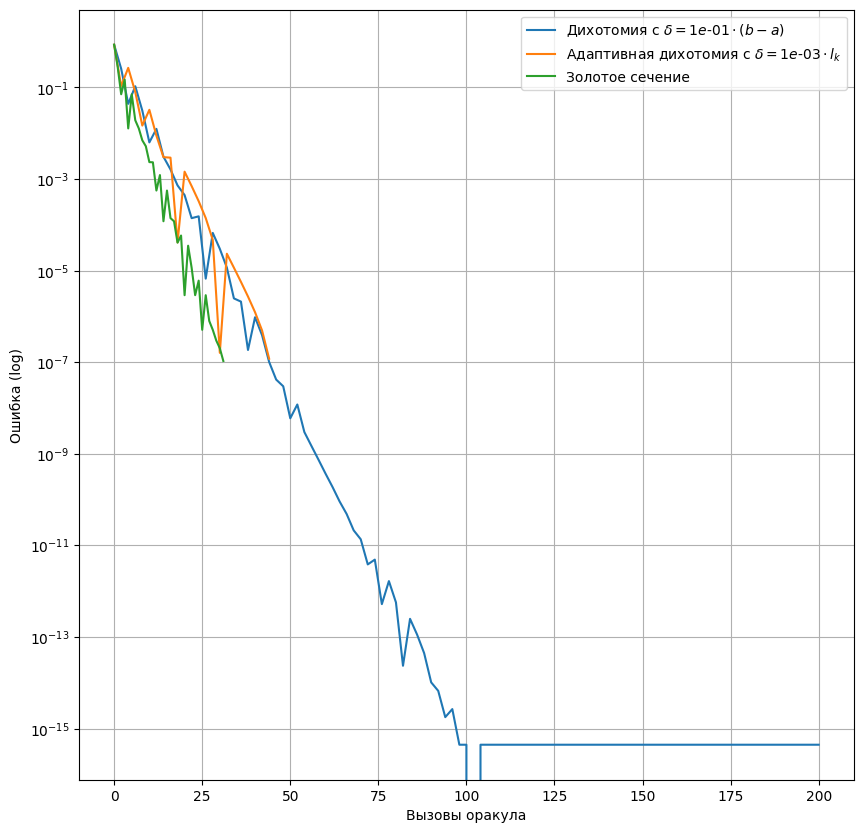

In [15]:
# Ваше решение (Code)
# Ваше решение (Code)
plt.figure(figsize=(10, 10))

c, history = dichotomy_method(f, a, b, c_star, delta=1e-1*(b-a))
fcalls = np.arange(len(history))*2
plt.plot(fcalls, history, label=f"Дихотомия с $\delta=1e$-$01\cdot (b-a)$")

c, history = dichotomy_adaptive(f, a, b, c_star, delta=lambda a,b: 1e-3*(b-a))
fcalls = np.arange(len(history))*2
plt.plot(fcalls, history, label=f"Адаптивная дихотомия с $\delta=1e$-$03\cdot l_k$")

c, history = golden_ratio_method(f, a, b, c_star)
fcalls = np.arange(len(history))
plt.plot(fcalls, history, label=f"Золотое сечение")

plt.xlabel("Вызовы оракула")
plt.ylabel("Ошибка (log)")
plt.legend()
plt.grid()
plt.yscale('log')
plt.show()

Что можно сказать о применимости метода золотого сечения? В чем он лучше по сравнению с методом дихотомии? 

__Решение__

Метод золотого сечения требует только 1 вызова оракула в шаге метода (вместо 2 вызовов у дихотомии) и при этом сходится с той же скоростью (или быстрее), т.е. он выгоден в задачах с высокой временной сложностью оракула.